In [1]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/asus/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
data=pd.read_csv("phishing_email.csv")
X=data['text_combined']
y=data['label']

In [3]:
data.head()
data.info()
print("Shape:", data.shape)
print("Columns:", data.columns.tolist())
data.isnull().sum()
print("Duplicate Rows:", data.duplicated().sum())
data["label"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82486 entries, 0 to 82485
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text_combined  82486 non-null  object
 1   label          82486 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.3+ MB
Shape: (82486, 2)
Columns: ['text_combined', 'label']
Duplicate Rows: 408


label
1    42891
0    39595
Name: count, dtype: int64

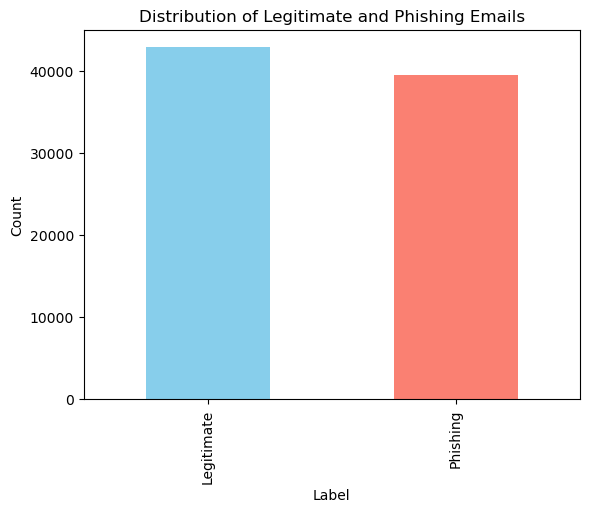

In [4]:
data["label"].value_counts().plot(kind="bar", color=["skyblue", "salmon"])
plt.title("Distribution of Legitimate and Phishing Emails")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks([0,1],["Legitimate","Phishing"])

plt.show()

In [5]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stop_words]
    return " ".join(words)


In [6]:
X= X.apply(clean_text)

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [8]:
vectorizer=TfidfVectorizer(max_features=5000)
X_vec=vectorizer.fit_transform(X)

In [9]:
X_train, X_test, y_train, y_test=train_test_split(X_vec,y,test_size=0.2,random_state=42)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
}

In [12]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,
    classification_report,confusion_matrix,ConfusionMatrixDisplay
)

Logistic Regression
Accuracy : 0.9804824827251788
Precision: 0.9768545307256105
Recall   : 0.9857526567791661
F1 Score : 0.9812834224598931
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      7935
           1       0.98      0.99      0.98      8563

    accuracy                           0.98     16498
   macro avg       0.98      0.98      0.98     16498
weighted avg       0.98      0.98      0.98     16498



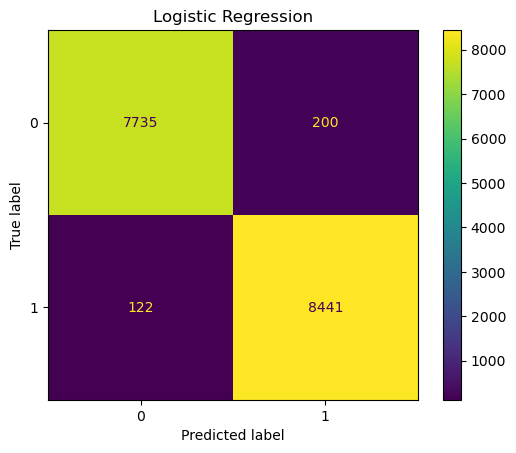

Random Forest
Accuracy : 0.9866044369014426
Precision: 0.9895539906103287
Recall   : 0.9845848417610651
F1 Score : 0.9870631622080431
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      7935
           1       0.99      0.98      0.99      8563

    accuracy                           0.99     16498
   macro avg       0.99      0.99      0.99     16498
weighted avg       0.99      0.99      0.99     16498



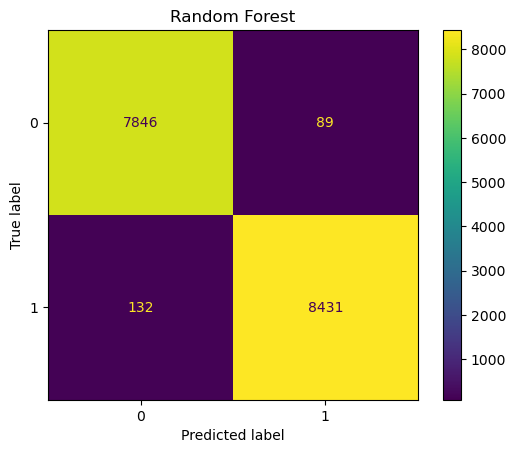

Naive Bayes
Accuracy : 0.9613286458964723
Precision: 0.9779278735978773
Recall   : 0.9468644166763984
F1 Score : 0.9621454847513943
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      7935
           1       0.98      0.95      0.96      8563

    accuracy                           0.96     16498
   macro avg       0.96      0.96      0.96     16498
weighted avg       0.96      0.96      0.96     16498



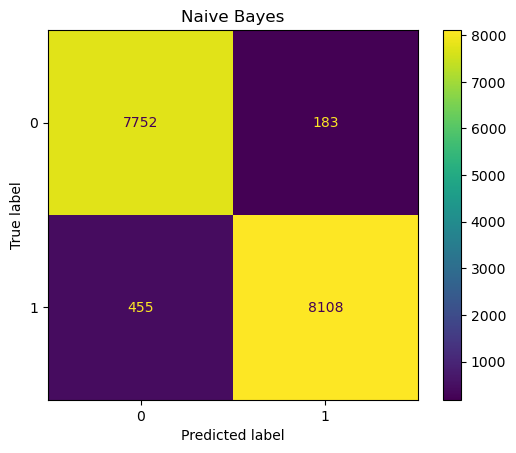

Neural Network
Accuracy : 0.9792096011637774
Precision: 0.9769087955442098
Recall   : 0.9831834637393437
F1 Score : 0.9800360863744835
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      7935
           1       0.98      0.98      0.98      8563

    accuracy                           0.98     16498
   macro avg       0.98      0.98      0.98     16498
weighted avg       0.98      0.98      0.98     16498



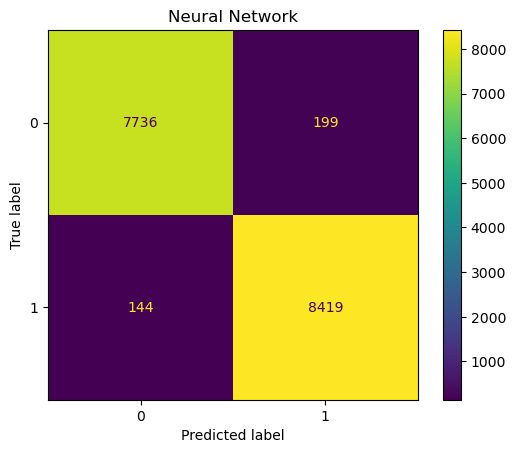

In [13]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    accuracy = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    results.append([name, accuracy, precision, recall, f1])

    print("="*60)
    print(name)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print(classification_report(y_test, preds))

    ConfusionMatrixDisplay.from_predictions(y_test, preds)
    plt.title(name)
    plt.show()

In [14]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.980482,0.976855,0.985753,0.981283
1,Random Forest,0.986604,0.989554,0.984585,0.987063
2,Naive Bayes,0.961329,0.977928,0.946864,0.962145
3,Neural Network,0.979210,0.976909,0.983183,0.980036


In [16]:
rf_model = models["Random Forest"]

feature_names = vectorizer.get_feature_names_out()
importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(20))

      Feature  Importance
4951    wrote    0.029163
1617    enron    0.023494
556       aug    0.021164
100      2008    0.021049
3447       pm    0.010445
4943    would    0.010330
2723     list    0.009689
4461    thank    0.009389
2811     mail    0.009161
4315  subject    0.009098
2995    money    0.008972
1820     file    0.008461
2333       im    0.007786
1259     date    0.007688
537    attach    0.007456
878        cc    0.007258
4854      wed    0.007132
3215  opensus    0.007087
989     click    0.007012
18         06    0.006887


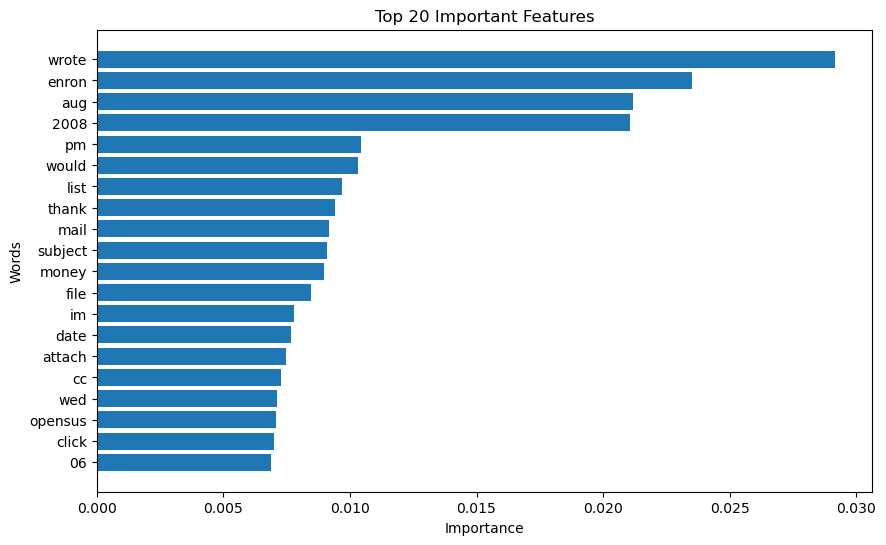

In [17]:
top20 = feature_importance.head(20)

plt.figure(figsize=(10,6))

plt.barh(top20["Feature"], top20["Importance"])

plt.title("Top 20 Important Features")
plt.xlabel("Importance")
plt.ylabel("Words")

plt.gca().invert_yaxis()

plt.show()

In [18]:
import joblib

joblib.dump(models["Random Forest"], "phishing_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model saved successfully!")

Model saved successfully!


In [23]:
user_email = input("Enter an email:\n")

cleaned = clean_text(user_email)

vector = vectorizer.transform([cleaned])

prediction = models["Random Forest"].predict(vector)

if prediction[0] == 1:
    print("⚠️ Phishing Email")
else:
    print("✅ Legitimate Email")

Enter an email:
 Subject: Invoice Attached  Hello,  Please find the invoice for your recent purchase attached.  If you have any questions, contact our billing department.  Regards, Finance Team


✅ Legitimate Email
